# NB04 - Regularizacion L2 (Ridge)

**Objetivos de aprendizaje**

- Entender por que la colinealidad puede inflar o inestabilizar coeficientes.
- Definir el penalti L2 y su relacion con `C = 1/lambda`.
- Visualizar rutas de coeficientes al variar la regularizacion.
- Comparar rendimiento train/test para discutir sesgo-varianza.
- Observar fronteras de decision con regularizacion fuerte y debil.

En todo el notebook mantenemos la convenci?n global del repositorio: `virginica = 1` es la clase positiva y `versicolor = 0` es la clase negativa.

**Referencias de este notebook**

- Hoerl & Kennard (1970): introducen Ridge para problemas mal condicionados y colineales.
- Hastie, Tibshirani & Friedman (2009): explican regularizacion y equilibrio sesgo-varianza.
- Murphy (2012): presenta la regularizacion desde una perspectiva probabilistica.


In [1]:
%matplotlib inline
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('png')
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

# Los notebooks pueden ejecutarse desde la raiz del repo o desde notebooks/.
# Este bloque localiza la raiz y agrega src/ al path de importacion.
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from utils import (
    COLOR_PALETTE,
    RANDOM_STATE,
    get_train_test_split,
    load_binary_iris,
    load_processed_splits,
    plot_coefficients,
    plot_decision_boundary,
    plot_regularization_path,
    plot_sigmoid,
    save_processed_splits,
    set_plot_style,
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
set_plot_style()
np.random.seed(RANDOM_STATE)

DATA_DIR = PROJECT_ROOT / "data" / "processed"

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


## 1. Motivacion: colinealidad y sobreajuste

En NB00 vimos que `petal length` y `petal width` estan fuertemente correlacionadas. Hoerl & Kennard (1970) propusieron Ridge para estabilizar estimaciones cuando las variables no son ortogonales.


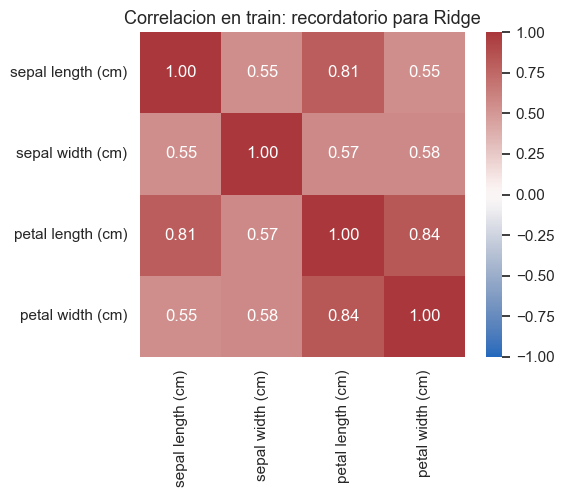

In [2]:
data = load_processed_splits(DATA_DIR)
X_train = data["X_train"]
X_test = data["X_test"]
X_train_scaled = data["X_train_scaled"]
X_test_scaled = data["X_test_scaled"]
y_train = data["y_train"]
y_test = data["y_test"]
feature_names = data["feature_names"]

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(X_train.corr(), annot=True, fmt=".2f", cmap="vlag", vmin=-1, vmax=1, square=True, ax=ax)
ax.set_title("Correlacion en train: recordatorio para Ridge")
fig.tight_layout()
plt.show()


**Interpretacion.** Las variables de petalo se mueven juntas. Sin regularizacion, el modelo puede asignar pesos grandes y compensatorios a variables que contienen informacion redundante.


## 2. Penalti L2

Ridge agrega `lambda * ||beta||^2` a la funcion de costo. Ese termino encoge coeficientes hacia cero, pero normalmente no los hace exactamente cero. En scikit-learn se controla con `C = 1/lambda`: `C` pequeno significa regularizacion fuerte.


## 3. Implementacion y ruta de coeficientes


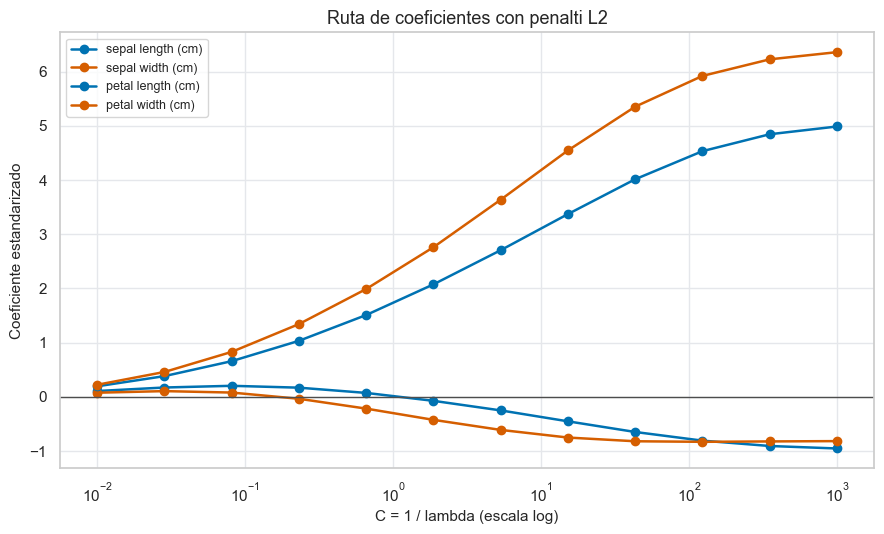

In [3]:
C_values = np.logspace(-2, 3, 12)
coefs = []
performance_rows = []

for C in C_values:
    # Ajustamos el mismo modelo para cada C sobre datos escalados, porque
    # la penalizacion L2 depende directamente de la escala de los coeficientes.
    model = LogisticRegression(
        penalty="l2",
        C=C,
        solver="lbfgs",
        max_iter=5000,
        random_state=RANDOM_STATE,
    )
    model.fit(X_train_scaled, y_train)
    coefs.append(model.coef_.ravel())

    train_prob = model.predict_proba(X_train_scaled)[:, 1]
    test_prob = model.predict_proba(X_test_scaled)[:, 1]
    performance_rows.append(
        {
            "C": C,
            "accuracy_train": accuracy_score(y_train, model.predict(X_train_scaled)),
            "accuracy_test": accuracy_score(y_test, model.predict(X_test_scaled)),
            "auc_train": roc_auc_score(y_train, train_prob),
            "auc_test": roc_auc_score(y_test, test_prob),
        }
    )

coefs = np.vstack(coefs)
performance = pd.DataFrame(performance_rows)
plot_regularization_path(C_values, coefs, feature_names, "Ruta de coeficientes con penalti L2")
plt.show()


**Interpretacion.** A la izquierda (`C` pequeno) todos los coeficientes se encogen. Al relajar la penalizacion, las variables mas informativas recuperan magnitud suavemente; Ridge estabiliza sin seleccionar variables exactamente.


## 4. Rendimiento y equilibrio sesgo-varianza


,C,accuracy_train,accuracy_test,auc_train,auc_test
0,0.0100,0.9000,0.7667,0.9894,0.9111
1,0.0285,0.9429,0.8667,0.9910,0.9422
2,0.0811,0.9714,0.8667,0.9959,0.9556
3,0.2310,0.9714,0.8667,0.9967,0.9733
4,0.6579,0.9571,0.9000,0.9976,0.9867
5,1.8738,0.9571,0.9333,0.9984,0.9911
6,5.3367,0.9571,0.9667,0.9984,0.9956
7,15.1991,0.9571,0.9667,0.9984,1.0000
8,43.2876,0.9571,0.9667,0.9984,0.9956
9,123.2847,0.9571,0.9667,0.9984,0.9956


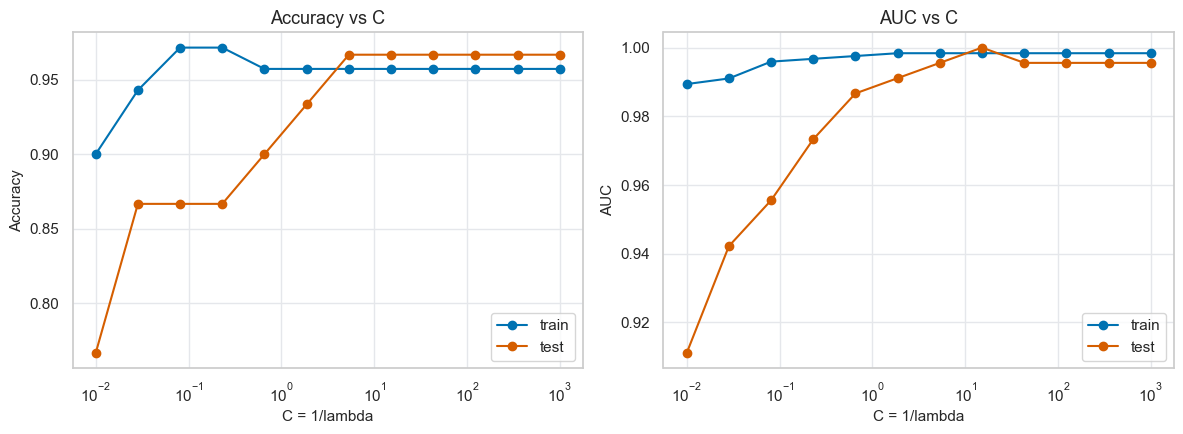

In [4]:
display(performance.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(performance["C"], performance["accuracy_train"], marker="o", label="train")
axes[0].plot(performance["C"], performance["accuracy_test"], marker="o", label="test")
axes[0].set_xscale("log")
axes[0].set_title("Accuracy vs C")
axes[0].set_xlabel("C = 1/lambda")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(performance["C"], performance["auc_train"], marker="o", label="train")
axes[1].plot(performance["C"], performance["auc_test"], marker="o", label="test")
axes[1].set_xscale("log")
axes[1].set_title("AUC vs C")
axes[1].set_xlabel("C = 1/lambda")
axes[1].set_ylabel("AUC")
axes[1].legend()
fig.tight_layout()
plt.show()


**Interpretacion.** Hastie, Tibshirani & Friedman (2009) describen esta tension como sesgo-varianza: demasiada penalizacion puede subajustar, muy poca puede volver el modelo mas variable. En este dataset pequeno, varias opciones rinden parecido, lo que tambien es una leccion practica.


## 5. Fronteras de decision con C fuerte y debil


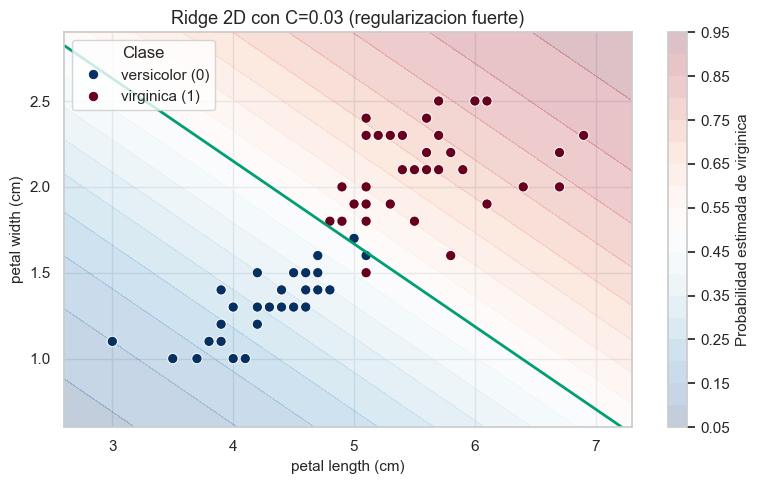

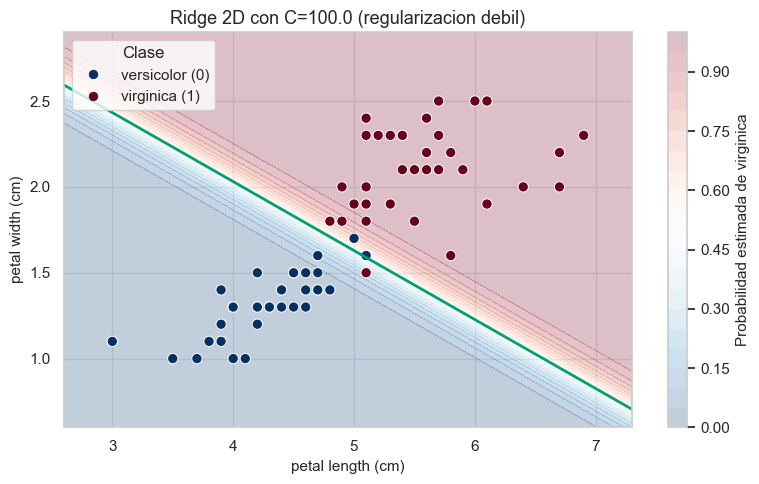

In [5]:
features_2d = ["petal length (cm)", "petal width (cm)"]

for C, label in [(0.03, "regularizacion fuerte"), (100.0, "regularizacion debil")]:
    model_2d = make_pipeline(
        StandardScaler(),
        LogisticRegression(penalty="l2", C=C, solver="lbfgs", max_iter=5000, random_state=RANDOM_STATE),
    )
    model_2d.fit(X_train[features_2d], y_train)
    plot_decision_boundary(
        model_2d,
        X_train[features_2d],
        y_train,
        features_2d,
        f"Ridge 2D con C={C} ({label})",
    )
    plt.show()


**Interpretacion.** Con regularizacion fuerte, la frontera es mas conservadora y los cambios de probabilidad son mas suaves. Con regularizacion debil, el modelo confia mas en los datos de entrenamiento y puede crear una transicion mas abrupta.


## Resumen y conexion con la literatura

Hoerl & Kennard (1970) introdujeron Ridge para estabilizar modelos con predictores colineales. Hastie, Tibshirani & Friedman (2009) explican el encogimiento L2 como herramienta de control de sesgo-varianza. Murphy (2012) conecta la penalizacion cuadratica con una lectura probabilistica: preferir coeficientes moderados antes que explicaciones excesivamente extremas.
